In [16]:

STUDENT_ROLL_NO = "24BAD046"
print(f"Running Part A - Student Roll No: {STUDENT_ROLL_NO}\n")

Running Part A - Student Roll No: 24BAD046



In [17]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [18]:
# 2. Load Dataset
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [19]:
# 3. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
# 4. Standardize Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# 5. Build ANN Model Architecture
model_reg = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)

In [22]:
# 6. Compile Model
model_reg.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [23]:
# 7. Train Model
history = model_reg.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.0788 - mae: 0.6692 - val_loss: 0.4824 - val_mae: 0.4916
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4123 - mae: 0.4571 - val_loss: 0.4152 - val_mae: 0.4646
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3748 - mae: 0.4360 - val_loss: 0.4005 - val_mae: 0.4459
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3640 - mae: 0.4270 - val_loss: 0.3961 - val_mae: 0.4420
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3513 - mae: 0.4197 - val_loss: 0.3841 - val_mae: 0.4502
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3372 - mae: 0.4104 - val_loss: 0.3606 - val_mae: 0.4194
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3319 - mae: 0.4055 - val_loss: 0.3629 - val_mae: 0.4300
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3227 - mae: 0.3997 - val_loss: 0.3529 - val_mae: 0.4081
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [24]:
# 8. Predictions & Evaluation
y_pred = model_reg.predict(X_test_scaled).flatten()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n" + "="*30)
print(f"REGRESSION EVALUATION RESULTS ({STUDENT_ROLL_NO})")
print("="*30)

print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root MSE (RMSE)          : {rmse:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

REGRESSION EVALUATION RESULTS (24BAD046)
Mean Squared Error (MSE) : 0.3047
Mean Absolute Error (MAE): 0.3717
Root MSE (RMSE)          : 0.5520


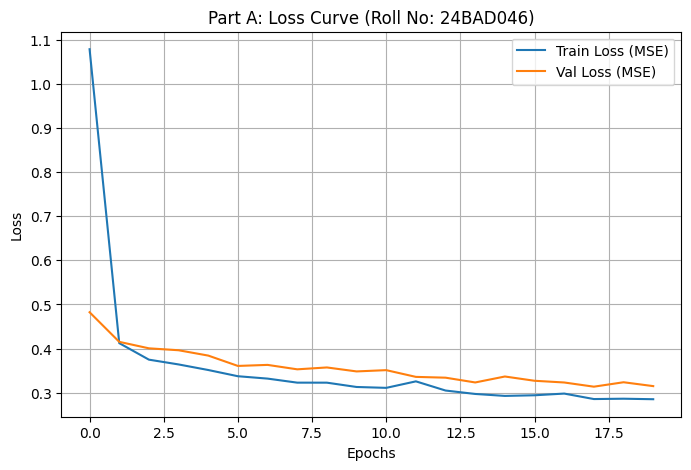

In [25]:


# Plot Loss Curves
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')

plt.title(f'Part A: Loss Curve (Roll No: {STUDENT_ROLL_NO})')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()